In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [132]:
df = pd.read_csv('/content/customer_churn_prediction_dataset.csv')

In [133]:
#1. See your Data.
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes


In [134]:
df.shape

(300, 21)

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        300 non-null    object 
 1   gender            300 non-null    object 
 2   SeniorCitizen     300 non-null    int64  
 3   Partner           300 non-null    object 
 4   Dependents        300 non-null    object 
 5   tenure            300 non-null    int64  
 6   PhoneService      300 non-null    object 
 7   MultipleLines     300 non-null    object 
 8   InternetService   300 non-null    object 
 9   OnlineSecurity    300 non-null    object 
 10  OnlineBackup      300 non-null    object 
 11  DeviceProtection  300 non-null    object 
 12  TechSupport       300 non-null    object 
 13  StreamingTV       300 non-null    object 
 14  StreamingMovies   300 non-null    object 
 15  Contract          300 non-null    object 
 16  PaperlessBilling  300 non-null    object 
 1

In [136]:
#EDA (Exploratory Data Analysis).
#1. Check null values
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [137]:
#2. Check for duplicates
df.duplicated().sum()

np.int64(0)

In [138]:
#3. Statistical terms
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,300.000000,300.000000,300.000000,300.000000
mean,0.543333,35.783333,67.226800,2477.975767
std,0.498951,21.113400,28.638073,1918.540111
min,0.000000,1.000000,18.450000,30.030000
25%,0.000000,17.000000,42.337500,910.302500
50%,1.000000,36.000000,68.635000,2072.400000
75%,1.000000,53.250000,92.430000,3618.405000
max,1.000000,72.000000,118.640000,8318.880000


In [139]:
#4. Outliers

In [140]:
# Class Imbalance

<Axes: xlabel='Churn', ylabel='count'>

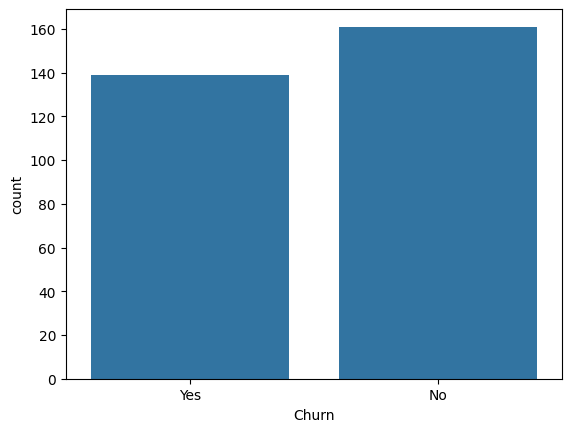

In [141]:
sns.countplot(x=df['Churn'])

In [142]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0001-XXXX,Male,0,Yes,Yes,5,No,Yes,No,No,...,No,No,No,No internet service,Month-to-month,Yes,Credit card,27.43,137.15,Yes
1,0002-XXXX,Female,0,No,No,42,Yes,No phone service,DSL,Yes,...,No,No,No internet service,No internet service,Two year,No,Electronic check,38.28,1607.76,Yes
2,0003-XXXX,Male,0,No,No,61,Yes,No phone service,No,No,...,No,Yes,Yes,No,One year,No,Bank transfer,106.44,6492.84,Yes
3,0004-XXXX,Male,1,No,Yes,22,Yes,No,No,No internet service,...,Yes,No,No internet service,Yes,Month-to-month,No,Electronic check,92.49,2034.78,No
4,0005-XXXX,Male,1,Yes,Yes,21,No,No,DSL,No,...,No internet service,No,No,No internet service,One year,No,Bank transfer,19.63,412.23,Yes


<Axes: xlabel='tenure', ylabel='Count'>

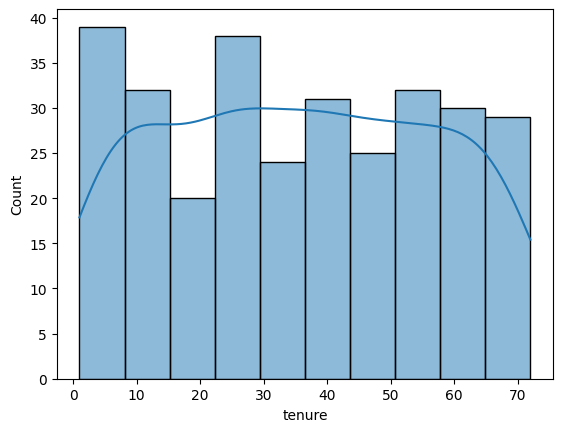

In [143]:
#Let's plot a histogram for skewneess
sns.histplot(df['tenure'],kde=True)

In [144]:
df['tenure'].skew()
#0  -> data centralized
#>0 -> Right skewed
#<0 -> Left Skewed

np.float64(0.02166595203393328)

In [145]:
df.drop(columns=['customerID'],axis=1,inplace=True)

In [146]:
#One hot Encoding

#list honi chahiye jiske andar sirf 'object' data aaye
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

In [147]:
cat_cols.remove('Churn')

In [148]:
cat_cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod']

In [149]:
df_copy = pd.get_dummies(df,columns=cat_cols)

In [150]:
df_copy

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,5,27.43,137.15,Yes,False,True,False,True,False,...,False,True,False,False,False,True,False,True,False,False
1,0,42,38.28,1607.76,Yes,True,False,True,False,True,...,False,False,False,True,True,False,False,False,True,False
2,0,61,106.44,6492.84,Yes,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
3,1,22,92.49,2034.78,No,False,True,True,False,False,...,True,True,False,False,True,False,False,False,True,False
4,1,21,19.63,412.23,Yes,False,True,False,True,False,...,False,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1,61,42.52,2593.72,No,True,False,True,False,False,...,False,False,True,False,False,True,False,False,True,False
296,0,49,22.31,1093.19,Yes,True,False,True,False,True,...,True,True,False,False,False,True,False,False,False,True
297,0,71,59.57,4229.47,Yes,False,True,True,False,False,...,True,False,False,True,True,False,False,False,False,True
298,1,1,31.32,31.32,No,False,True,False,True,False,...,True,False,False,True,True,False,False,True,False,False


In [151]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df_copy['Churn'] =  le.fit_transform(df['Churn'])

In [152]:
df_copy

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,5,27.43,137.15,1,False,True,False,True,False,...,False,True,False,False,False,True,False,True,False,False
1,0,42,38.28,1607.76,1,True,False,True,False,True,...,False,False,False,True,True,False,False,False,True,False
2,0,61,106.44,6492.84,1,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
3,1,22,92.49,2034.78,0,False,True,True,False,False,...,True,True,False,False,True,False,False,False,True,False
4,1,21,19.63,412.23,1,False,True,False,True,False,...,False,False,True,False,True,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295,1,61,42.52,2593.72,0,True,False,True,False,False,...,False,False,True,False,False,True,False,False,True,False
296,0,49,22.31,1093.19,1,True,False,True,False,True,...,True,True,False,False,False,True,False,False,False,True
297,0,71,59.57,4229.47,1,False,True,True,False,False,...,True,False,False,True,True,False,False,False,False,True
298,1,1,31.32,31.32,0,False,True,False,True,False,...,True,False,False,True,True,False,False,True,False,False


In [153]:
#Split X and y variables for model training and testing
X = df_copy.drop(columns=['Churn'])
y = df_copy['Churn']

In [154]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [155]:
#building model

from sklearn.linear_model import LogisticRegression
logistic=LogisticRegression()


In [156]:
#training model
logistic.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [158]:
#prediction model
y_pred=logistic.predict(X_test)
y_pred

array([0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1])

In [159]:
#evaluate model
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

#1. acuurancy_score
print(f"Acuurancy score for training {accuracy_score(y_test,y_pred)}")

Acuurancy score for training 0.4666666666666667


In [160]:
print(f"Acuurancy score for training {accuracy_score(y_train,logistic.predict(X_train))}")

Acuurancy score for training 0.6916666666666667


<Axes: >

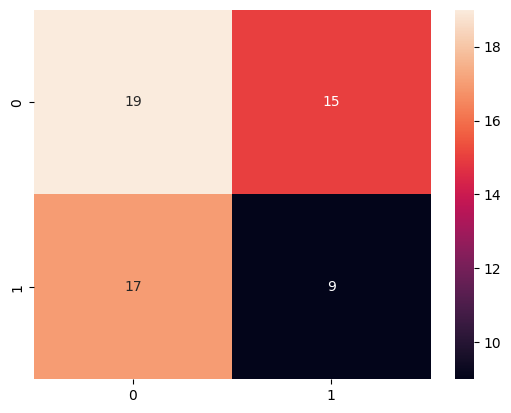

In [161]:
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True)

In [162]:
#importing the model to create  dashing ui
import joblib
joblib.dump(logistic,'logistic.pkl')

['logistic.pkl']